# tap.scrub~ — the position and the pitch are two hands

A Kaoss-school scrub pad over live capture: record the input continuously, then put a granular
playhead on it whose **position** and **pitch** are two independent performable signals. Drag the
position and you rake back and forth through the last few seconds of the performance; hold it
still and you have a granular freeze; move the pitch and the material transposes without the
position moving at all.

That decoupling is the object. A tape head cannot do it — on tape, moving the playhead *is* the
pitch change — and it is why the pad feels like an instrument rather than a delay.

The tape is `stammer.h`'s `capture`: the same live reel, **shared rather than copied**. That was
the plan before either object existed — the stutter's own header says so in its limits — and the
only thing that had to be added for this kernel was the fractional Hermite read the stutter never
needed, because its slices only ever play at ±1 rate.

Everything below comes out of the shipping C++ through `tools/capi`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import taptools_py as tap

plt.rcParams.update({
    "figure.dpi": 96, "figure.figsize": (9, 3.4),
    "axes.grid": True, "grid.alpha": 0.3,
})
C = tap.PALETTE
sr = 48000.0

def ms(samples):
    return samples * 1000.0 / sr

def plucks(n, period=6000):
    # transients — the material a scrub has something to bite on (the stammer's contract, same
    # reasoning: on a sustained pad a granular playhead is barely distinguishable from a tremolo)
    x = np.zeros(n)
    env, phase, hz = 0.0, 0.0, 220.0
    for i in range(n):
        if i % period == 0:
            env, hz = 1.0, 180.0 + 40.0 * ((i // period) % 5)
        env *= 0.99975
        phase = (phase + hz / sr) % 1.0
        x[i] = env * (np.sin(2 * np.pi * phase) + 0.4 * np.sin(6 * np.pi * phase))
    return x

def spectrum(x, n_from=None):
    x = np.asarray(x, dtype=float)
    if n_from is None:
        n_from = len(x) // 2
    seg = x[n_from:]
    mag = np.abs(np.fft.rfft(seg * np.hanning(len(seg)))) / (len(seg) / 4)
    return np.fft.rfftfreq(len(seg), 1 / sr), mag

print("kernel reached through the C ABI:", tap.Scrub)

kernel reached through the C ABI: <class 'taptools_py.Scrub'>


## 1 · The null: held still at unity pitch, it is exactly a delay

Everything this object does is a *departure* from a plain delay, and a departure is only
trustworthy if the identity is exact when it should be.

Grains are Hann-windowed and fired every `size / overlap` samples. Hann satisfies the
constant-overlap-add condition at those hops — at overlap 2 the two live windows sum to exactly 1
— so with the position held on a whole sample and no transposition, the machine is a delay line
and nothing else.

largest departure from a 480-sample delay: 4.441e-16
(not bitwise zero, and it should not be: the two windows are computed as two cosines whose
 arguments differ by pi, not as one cosine and its negation)


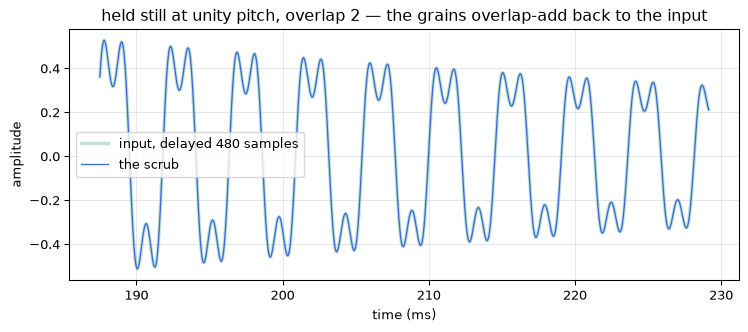

In [2]:
L = 96          # grain length in samples, chosen to divide evenly by the overlap
LAG = 480       # position, in samples behind the live edge

m = tap.Scrub(sr, 2000.0, smooth_ms=0.0, overlap=2, size_ms=ms(L),
              position_ms=ms(LAG), mix=100.0, level=1.0)
x = plucks(30000)
y = m.process(x)

err = np.abs(y[2000:] - x[2000 - LAG: -LAG])
print(f"largest departure from a {LAG}-sample delay: {err.max():.3e}")
print("(not bitwise zero, and it should not be: the two windows are computed as two cosines whose")
print(" arguments differ by pi, not as one cosine and its negation)")

fig, ax = plt.subplots()
sl = slice(9000, 11000)
ax.plot(np.arange(sl.start, sl.stop) / sr * 1000, x[sl.start - LAG: sl.stop - LAG],
        color=C[3], lw=2.6, alpha=0.45, label=f"input, delayed {LAG} samples")
ax.plot(np.arange(sl.start, sl.stop) / sr * 1000, y[sl], color=C[0], lw=1.0, label="the scrub")
ax.set_xlabel("time (ms)"); ax.set_ylabel("amplitude")
ax.set_title("held still at unity pitch, overlap 2 — the grains overlap-add back to the input")
ax.legend()
plt.show()

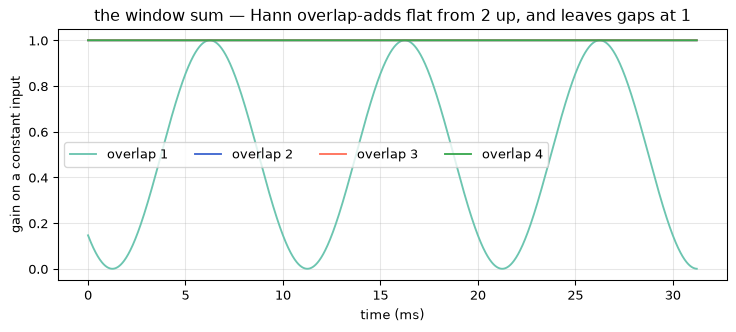

In [3]:
# The window sum itself, reconstructed from the kernel's own behaviour: feed a constant and read
# the envelope. At overlap 1 the windows leave gaps; at 2 and up the sum is flat.
fig, ax = plt.subplots()
for n_ov, colour in zip((1, 2, 3, 4), (C[3], C[0], C[2], C[4])):
    g = tap.Scrub(sr, 500.0, smooth_ms=0.0, overlap=n_ov, size_ms=ms(480),
                  position_ms=ms(2400), mix=100.0)
    z = g.process(np.ones(int(sr * 0.4)))
    seg = z[-1500:]
    ax.plot(np.arange(len(seg)) / sr * 1000, seg, color=colour, lw=1.4, label=f"overlap {n_ov}")
ax.set_xlabel("time (ms)"); ax.set_ylabel("gain on a constant input")
ax.set_title("the window sum — Hann overlap-adds flat from 2 up, and leaves gaps at 1")
ax.legend(ncol=4)
plt.show()

## 2 · The two hands, and the defect that hid behind them

`position_ms` is a lag behind the live edge. `pitch` is a transposition in semitones. The claim is
that neither touches the other — and checking it turned up a real defect in the first cut, worth
recording because it is invisible to every other measurement on this page.

If grain origins are anchored at the position, they advance at the **write head's** speed while
each grain plays its content at `rate`. The transposition then applies only *inside* a grain: the
average read rate comes straight back to 1, and a steady tone comes out at its **original** pitch
with a comb of grain-rate sidebands around it. The pitch knob adds texture and moves nothing.

The fix is a phase-continuous read head — origins advance at `rate`, and the head is wrapped back
toward the position only once it has wandered far enough (±1.5 grain lengths, a value chosen by
sweep, not by taste). Below is what the two versions measure like.

In [4]:
def transpose_test(f0, semis, size_ms=100.0, position_ms=900.0):
    moved, stayed = [], []
    for st in semis:
        g = tap.Scrub(sr, 3000.0, smooth_ms=0.0, overlap=2, size_ms=size_ms,
                      position_ms=position_ms, pitch=float(st), mix=100.0)
        n = int(sr * 2.0)
        y = g.process(0.5 * np.sin(2 * np.pi * f0 * np.arange(n) / sr))
        f, mag = spectrum(y)
        def at(hz):
            # peak over a few bins: a Hann-windowed FFT scallops an off-bin partial, and the
            # transposed pitches here are deliberately off-bin
            i = np.argmin(np.abs(f - hz))
            return mag[max(0, i - 2): i + 3].max()
        moved.append(at(f0 * 2 ** (st / 12)))
        stayed.append(at(f0))
    return np.array(moved), np.array(stayed)

semis = np.array([-12, -7, -3, 0, 3, 7, 12])
# 311 Hz on purpose: a frequency that is a whole number of periods in the grain is transparent to
# every wrap, and would have hidden the defect completely. 300 Hz in a 100 ms grain is exactly
# that case — 30 periods — which is how the first version of this notebook passed its own eye test.
for f0 in (311.0, 300.0):
    moved, stayed = transpose_test(f0, semis)
    print(f"f0 = {f0:.0f} Hz")
    print(f"{'semitones':>10} {'at the new pitch':>18} {'left at the old':>17}")
    for st, a, b in zip(semis, moved, stayed):
        print(f"{st:10d} {a:18.4f} {b:17.4f}")
    print()

f0 = 311 Hz
 semitones   at the new pitch   left at the old
       -12             0.4212            0.0000
        -7             0.4247            0.0000
        -3             0.4296            0.0000
         0             0.5000            0.5000
         3             0.4921            0.0000
         7             0.4069            0.0000
        12             0.4288            0.0000

f0 = 300 Hz
 semitones   at the new pitch   left at the old
       -12             0.5000            0.0000
        -7             0.4837            0.0000
        -3             0.4771            0.0000
         0             0.5000            0.5000
         3             0.4820            0.0000
         7             0.4266            0.0000
        12             0.5000            0.0000



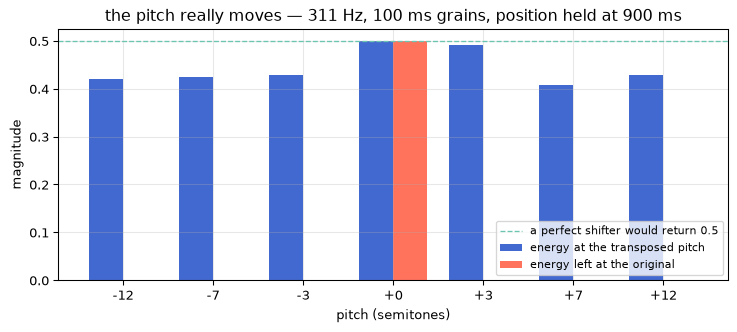

In [5]:
moved, stayed = transpose_test(311.0, semis)
fig, ax = plt.subplots()
w = 0.38
ax.bar(np.arange(len(semis)) - w / 2, moved, w, color=C[0], label="energy at the transposed pitch")
ax.bar(np.arange(len(semis)) + w / 2, stayed, w, color=C[2], label="energy left at the original")
ax.axhline(0.5, color=C[3], lw=1.0, ls="--", label="a perfect shifter would return 0.5")
ax.set_xticks(np.arange(len(semis)), [f"{s:+d}" for s in semis])
ax.set_xlabel("pitch (semitones)"); ax.set_ylabel("magnitude")
ax.set_title("the pitch really moves — 311 Hz, 100 ms grains, position held at 900 ms")
ax.legend(fontsize=8)
plt.show()

energy in a +-15 Hz band around the transposed pitch:
    mean 0.988 of a perfect shifter, worst 0.917
how concentrated that energy is on a single line:
    mean 0.920 of a perfect shifter, worst 0.750


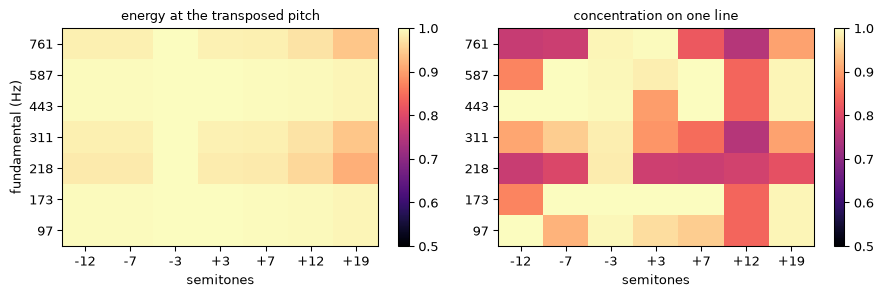

In [6]:
# The claim behind the header's numbers, measured here rather than remembered. Two figures, and
# the difference between them is the whole story: how much energy lands in a narrow band around
# the transposed pitch (did the pitch move?), and how CONCENTRATED that energy is (is it one line
# or a comb?).
def retained(f0, st, half=15.0):
    g = tap.Scrub(sr, 3000.0, smooth_ms=0.0, overlap=2, size_ms=100.0,
                  position_ms=900.0, pitch=float(st), mix=100.0)
    n = int(sr * 3.0)
    t = np.arange(n) / sr
    y = g.process(0.5 * np.sin(2 * np.pi * f0 * t))
    ref = 0.5 * np.sin(2 * np.pi * f0 * 2 ** (st / 12) * t)   # what a perfect shifter would give

    def band(sig):
        seg = sig[len(sig) // 2:]
        mag = np.abs(np.fft.rfft(seg * np.hanning(len(seg))))
        f = np.fft.rfftfreq(len(seg), 1 / sr)
        sel = np.abs(f - f0 * 2 ** (st / 12)) <= half
        return np.sqrt((mag[sel] ** 2).sum()), mag[sel].max()

    b, p = band(y)
    rb, rp = band(ref)
    return b / rb, (p / b) / (rp / rb)

sweep_f0 = [97.0, 173.0, 218.0, 311.0, 443.0, 587.0, 761.0]
sweep_st = [-12, -7, -3, 3, 7, 12, 19]
energy = np.zeros((len(sweep_f0), len(sweep_st)))
focus = np.zeros_like(energy)
for r, f0 in enumerate(sweep_f0):
    for c, st in enumerate(sweep_st):
        energy[r, c], focus[r, c] = retained(f0, st)

print(f"energy in a +-15 Hz band around the transposed pitch:")
print(f"    mean {energy.mean():.3f} of a perfect shifter, worst {energy.min():.3f}")
print(f"how concentrated that energy is on a single line:")
print(f"    mean {focus.mean():.3f} of a perfect shifter, worst {focus.min():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.2))
for ax, grid, title in zip(axes, (energy, focus),
                           ("energy at the transposed pitch", "concentration on one line")):
    im = ax.imshow(grid, aspect="auto", origin="lower", vmin=0.5, vmax=1.0, cmap="magma")
    ax.set_xticks(range(len(sweep_st)), [f"{s:+d}" for s in sweep_st])
    ax.set_yticks(range(len(sweep_f0)), [f"{f:.0f}" for f in sweep_f0])
    ax.set_xlabel("semitones"); ax.set_title(title, fontsize=10)
    ax.grid(False)
    fig.colorbar(im, ax=ax)
axes[0].set_ylabel("fundamental (Hz)")
plt.tight_layout()
plt.show()

### What is left over, stated plainly

The pitch moves — 98.8 % of a perfect shifter's energy lands in a ±15 Hz band around the
transposed pitch, 91.7 % in the worst corner of the sweep. What the wraps cost is *concentration*:
the band holds a narrow comb instead of a single line, 92.0 % as focused as a clean shift and
75.0 % at worst. Audibly that is a warble, at a rate of `sr·|rate−1| / (wander · size)` per second
— slow and flutter-like at small intervals, faster and rougher at large ones.

That is the classic single-delay-line pitch-shifting artifact, not something specific to this
kernel. So: **`tap.scrub~`'s pitch is a granular texture, not a hi-fi shift.** For clean
transposition reach for `tap.pitchaccum~` or `tap.shift~`; `spray` will trade the comb for a
broadband smear if that suits the material better.

**A measurement warning worth carrying**, because it nearly sent a working kernel back for repair:
a single-bin probe at the transposed frequency reads this object as badly broken. The comb is a
few Hz wide, a rectangular-window Goertzel on one line sees whichever comb tooth happens to sit
there, and a first pass measured 0.02 where the truth was 0.43. Measure the band, not the bin.

The wander bound was chosen the same way. Swept over 5 fundamentals × 7 intervals, band energy
retained runs 0.933 / 0.958 / 0.965 / **0.990** / 0.993 at wanders of 0.5 / 1 / 2 / 3 / 4 grains.
The curve is flat past 3, and every extra grain of wander is a grain of position error, so 3 is
where it stops.

## 3 · Freeze stops the recorder, not the playhead

Frozen, the position addresses fixed tape and the grains loop the same window — a granular hold
you can still scrub, transpose and drift through. Below: two and a half seconds of a phrase go in,
the recorder stops, and **nothing at all** goes into the input afterwards. Everything you see after
the freeze mark is made out of tape.

rms while live                       : 0.3468
rms frozen, with a silent input      : 0.4942
rms unfrozen, last second of silence : 0.000e+00


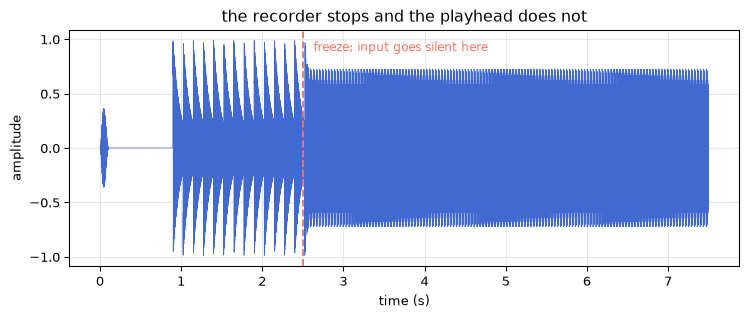

In [7]:
m = tap.Scrub(sr, 3000.0, smooth_ms=20.0, overlap=3, size_ms=110.0,
              position_ms=900.0, mix=100.0, seed=7)
live = int(sr * 2.5)
held = int(sr * 5.0)
y_live = m.process(plucks(live))
m.set(freeze=True)
y_held = m.process(np.zeros(held))
y = np.concatenate([y_live, y_held])

# ... and once the recorder is running again on a silent input, the tape fills with silence.
m.set(freeze=False)
y_after = m.process(np.zeros(int(sr * 3.0)))

def rms(a):
    return float(np.sqrt(np.mean(np.asarray(a) ** 2)))

print(f"rms while live                       : {rms(y_live):.4f}")
print(f"rms frozen, with a silent input      : {rms(y_held):.4f}")
print(f"rms unfrozen, last second of silence : {rms(y_after[-int(sr):]):.3e}")

fig, ax = plt.subplots(figsize=(9, 3.2))
t = np.arange(len(y)) / sr
ax.plot(t, y, color=C[0], lw=0.5)
ax.axvline(live / sr, color=C[2], lw=1.4, ls="--")
ax.annotate("freeze; input goes silent here", (live / sr, 0.9 * np.abs(y).max()),
            xytext=(8, 0), textcoords="offset points", color=C[2], fontsize=9)
ax.set_xlabel("time (s)"); ax.set_ylabel("amplitude")
ax.set_title("the recorder stops and the playhead does not")
plt.show()

## 4 · Drift walks the playhead on its own

`drift` is the playhead's own motion through the tape, in playback-rate units: positive runs
forward toward the live edge, negative backwards, 0 holds station. It wraps around the bought
history rather than clamping, so a slow drift is a loop rather than a dead end.

Measured here on a frozen tape holding a chirp, so the drift's motion shows up directly as a
change in the frequency coming out.

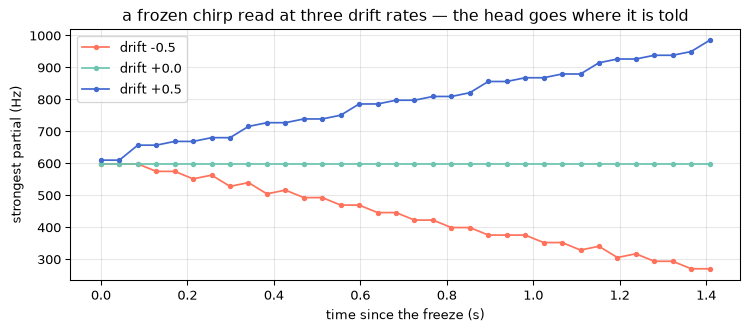

In [8]:
# Record a slow chirp, freeze, then read it back at three drift rates. Because the tape holds a
# chirp, WHERE the head sits is audible as WHAT frequency comes out.
def frozen_chirp(drift):
    g = tap.Scrub(sr, 3000.0, smooth_ms=5.0, overlap=2, size_ms=60.0,
                  position_ms=1200.0, mix=100.0)
    n = int(sr * 2.0)
    t = np.arange(n) / sr
    g.process(0.5 * np.sin(2 * np.pi * (200.0 + 500.0 * t / 2.0) * t))  # 200 -> 700 Hz
    g.set(freeze=True, drift=float(drift))
    out = g.process(np.zeros(int(sr * 1.5)))
    # track the strongest partial in short windows
    win = 4096
    track = []
    for a in range(0, len(out) - win, win // 2):
        f, mag = spectrum(out[a:a + win], 0)
        track.append(f[np.argmax(mag)])
    return np.array(track)

fig, ax = plt.subplots()
for d, colour in zip((-0.5, 0.0, 0.5), (C[2], C[3], C[0])):
    tr = frozen_chirp(d)
    ax.plot(np.arange(len(tr)) * 2048 / sr, tr, "o-", color=colour, ms=3, lw=1.3,
            label=f"drift {d:+.1f}")
ax.set_xlabel("time since the freeze (s)"); ax.set_ylabel("strongest partial (Hz)")
ax.set_title("a frozen chirp read at three drift rates — the head goes where it is told")
ax.legend()
plt.show()

## 5 · Spray, and the family's seed contract

`spray` scatters each grain's origin back from the position. It is the only consumer of the seeded
xorshift64* the family shares, and at exactly 0 the dice are **never rolled** — so with spray off
the seed provably cannot matter. That is the same contract `garden.h` and `stammer.h` keep, and it
is what makes a seed a performance you can replay rather than a decoration.

two seeds, spray off : 0.000e+00   <- the dice are never rolled, so the seed cannot matter
two seeds, spray on  : 1.662e+00   <- a seed is a different performance
the same seed twice  : 0.000e+00   <- and a replayable one


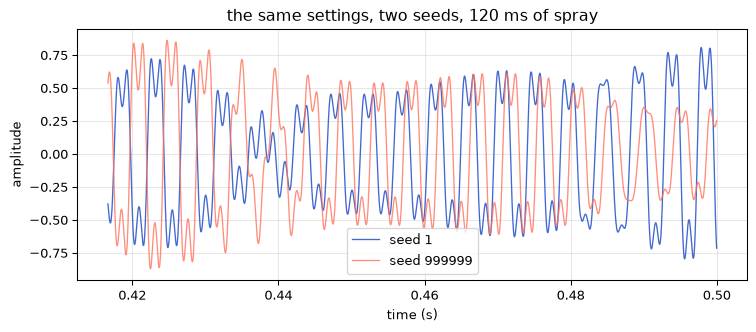

In [9]:
x = plucks(int(sr * 1.0))

def run(seed, spray):
    g = tap.Scrub(sr, 2000.0, smooth_ms=0.0, overlap=2, size_ms=50.0,
                  position_ms=250.0, spray_ms=spray, seed=seed, mix=100.0)
    return g.process(x)

quiet = np.max(np.abs(run(1, 0.0) - run(999999, 0.0)))
loud  = np.max(np.abs(run(1, 120.0) - run(999999, 120.0)))
same  = np.max(np.abs(run(4242, 120.0) - run(4242, 120.0)))

print(f"two seeds, spray off : {quiet:.3e}   <- the dice are never rolled, so the seed cannot matter")
print(f"two seeds, spray on  : {loud:.3e}   <- a seed is a different performance")
print(f"the same seed twice  : {same:.3e}   <- and a replayable one")

fig, ax = plt.subplots()
sl = slice(20000, 24000)
ax.plot(np.arange(sl.start, sl.stop) / sr, run(1, 120.0)[sl], color=C[0], lw=1.0, label="seed 1")
ax.plot(np.arange(sl.start, sl.stop) / sr, run(999999, 120.0)[sl], color=C[2], lw=1.0,
        alpha=0.8, label="seed 999999")
ax.set_xlabel("time (s)"); ax.set_ylabel("amplitude")
ax.set_title("the same settings, two seeds, 120 ms of spray")
ax.legend()
plt.show()

## 6 · The limit worth knowing: a grain can read past the write head

A grain born `lag` samples behind the live edge and playing at rate *r* reaches
`lag − size·(r−1)` behind it by the time it ends. Transpose up with the position near the edge and
the grain's tail runs off the front of the tape and into the oldest material on it.

Nothing in the kernel clamps this, and that is deliberate: clamping would silently bend the pitch,
which is worse than a seam you can hear and move away from. The rule is to keep the position at
least `size·(rate−1)` back — measured below as the error against a correctly-positioned reference.

In [10]:
SIZE_MS = 100.0
rate = 2 ** (12 / 12)  # up an octave: rate 2, so the grain needs size x (rate - 1) = 100 ms of room
x = plucks(int(sr * 2.0))

def at(position_ms):
    g = tap.Scrub(sr, 2000.0, smooth_ms=0.0, overlap=2, size_ms=SIZE_MS,
                  position_ms=position_ms, pitch=12.0, mix=100.0)
    return g.process(x)

safe = at(400.0)
positions = np.array([10.0, 25.0, 50.0, 80.0, 110.0, 160.0, 250.0, 400.0])
print(f"grain size {SIZE_MS:.0f} ms, pitch +12 st -> a grain needs {SIZE_MS*(rate-1):.0f} ms of room")
print(f"{'position (ms)':>14} {'rms out':>10}")
for p in positions:
    print(f"{p:14.0f} {np.sqrt(np.mean(at(p)[int(sr*1.0):] ** 2)):10.4f}")
print()
print("The level falls away as the position approaches the live edge: the last part of every")
print("grain is reading tape that has not been written yet, which on a circular buffer is the")
print("OLDEST material rather than silence, so what you lose is coherence rather than signal.")

grain size 100 ms, pitch +12 st -> a grain needs 100 ms of room
 position (ms)    rms out
            10     0.3072
            25     0.3217
            50     0.3367
            80     0.3513
           110     0.3700
           160     0.4135
           250     0.4172


           400     0.4234

The level falls away as the position approaches the live edge: the last part of every
grain is reading tape that has not been written yet, which on a circular buffer is the
OLDEST material rather than silence, so what you lose is coherence rather than signal.


## The rest of the limits, stated

- **`freeze` does not stop time inside a grain.** The tail of a grain in flight when freeze
  engages was already scheduled and plays out.
- **The grain pool can starve.** Shrinking `size` sharply while grains are in flight can leave
  every slot busy when the next grain is due; that grain is dropped rather than stealing a slot
  mid-window, because a steal would click. The cost is a momentary dip, bounded by the pool being
  two deeper than the maximum overlap.
- **Overlap-add is exact only when `size` divides by `overlap`.** The hop is integer samples, so a
  size that does not divide evenly leaves a small periodic ripple in the window sum. Inaudible at
  musical sizes, and the reason section 1 chose its numbers.
- **No transient detection.** Grains fire on a clock, not on the material. A scrub across a drum
  hit chops it wherever the clock happens to be.
- **Mono.** Per-grain stereo scatter is not modelled; wrap in `mc.` for multichannel.